In [16]:
import requests
import pandas as pd


def extraer_serie_ine(codigo_serie, nult=300):
    url = f"https://servicios.ine.es/wstempus/js/ES/DATOS_SERIE/{codigo_serie}?nult={nult}"

    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
    except requests.exceptions.Timeout:
        print(f'Timeout al consultar la serie {codigo_serie}')
        return None
    except requests.exceptions.RequestException as e:
        print(f'Error al consultar la serie {e}')
        return None
    
    if 'Data' not in data:
        print(f'La respuesta no contiene datos para {codigo_serie}')
        
    registros = [
        {
            'fecha': entry['Fecha'],
            'valor': entry['Valor'],
        }
        for entry in data['Data']
    ]

    df = pd.DataFrame(registros)
    df['fecha'] = pd.to_datetime(df['fecha'], unit='ms')
    df = df.sort_values('fecha').reset_index(drop=True)
    
    return df

In [17]:
df_icm = extraer_serie_ine('ICM3821')
df_ipc = extraer_serie_ine('IPC251852', 350)

df_icm['fecha'] = df_icm['fecha'].dt.to_period('M').dt.to_timestamp()
df_ipc['fecha'] = df_ipc['fecha'].dt.to_period('M').dt.to_timestamp()

df_icm.to_csv('../data/raw/icm_general.csv', index=False)
df_ipc.to_csv('../data/raw/ipc_general.csv', index=False)

In [4]:
# Merge de ICM e IPC
df = pd.merge(df_icm, df_ipc, on='fecha', how='left', suffixes=('_icm', '_ipc'))
print(df.shape)
print(df.isnull().sum())

(300, 3)
fecha         0
valor_icm     0
valor_ipc    12
dtype: int64


In [5]:
df.columns.tolist()

['fecha', 'valor_icm', 'valor_ipc']

## Visualizacion de serie completa

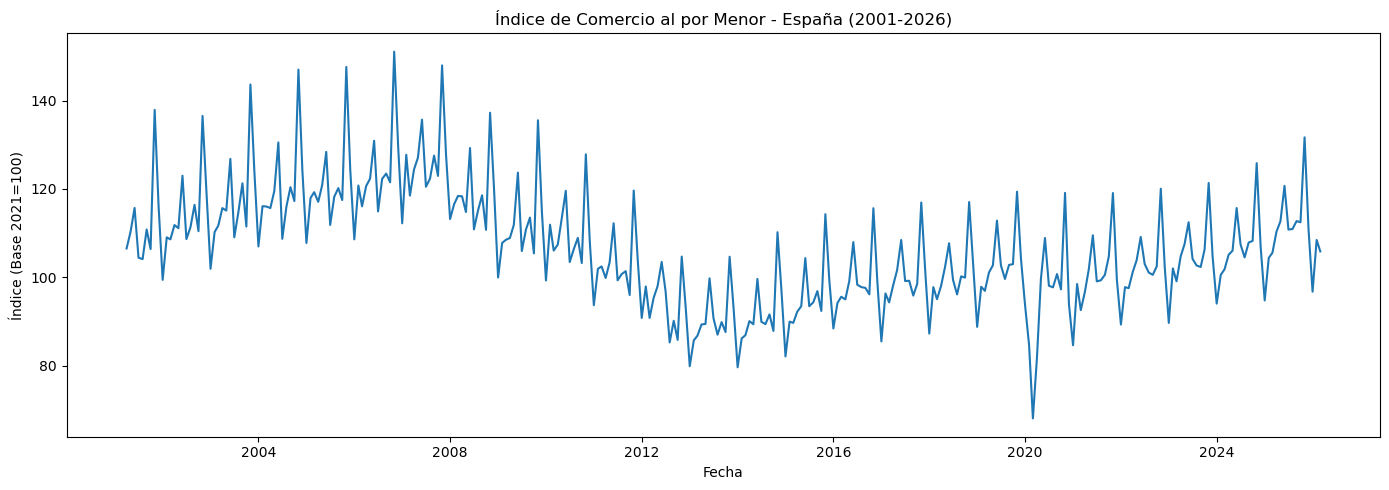

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['fecha'], df['valor_icm'])
ax.set_title('Índice de Comercio al por Menor - España (2001-2026)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Índice (Base 2021=100)')
plt.tight_layout()
plt.savefig('../reports/figures/01_serie_completa.png', dpi=150)
plt.show()

In [7]:
print(df.loc[df['valor_icm'].idxmin()])

fecha        2020-03-01 00:00:00
valor_icm                 68.032
valor_ipc                 96.944
Name: 227, dtype: object


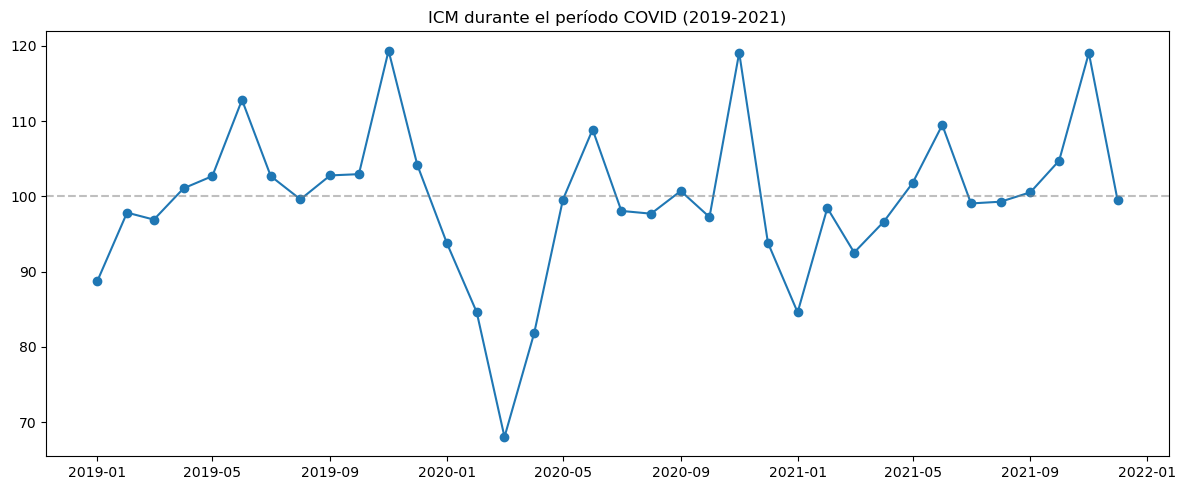

In [8]:
# Analisis del ICM durante el COVID
mask = (df['fecha'] >= '2019-01-01') & (df['fecha'] <= '2021-12-31')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.loc[mask, 'fecha'], df.loc[mask, 'valor_icm'], marker='o')
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('ICM durante el período COVID (2019-2021)')
plt.tight_layout()
plt.savefig('../reports/figures/02_covid_zoom.png', dpi=150)
plt.show()

## Descomposición STL

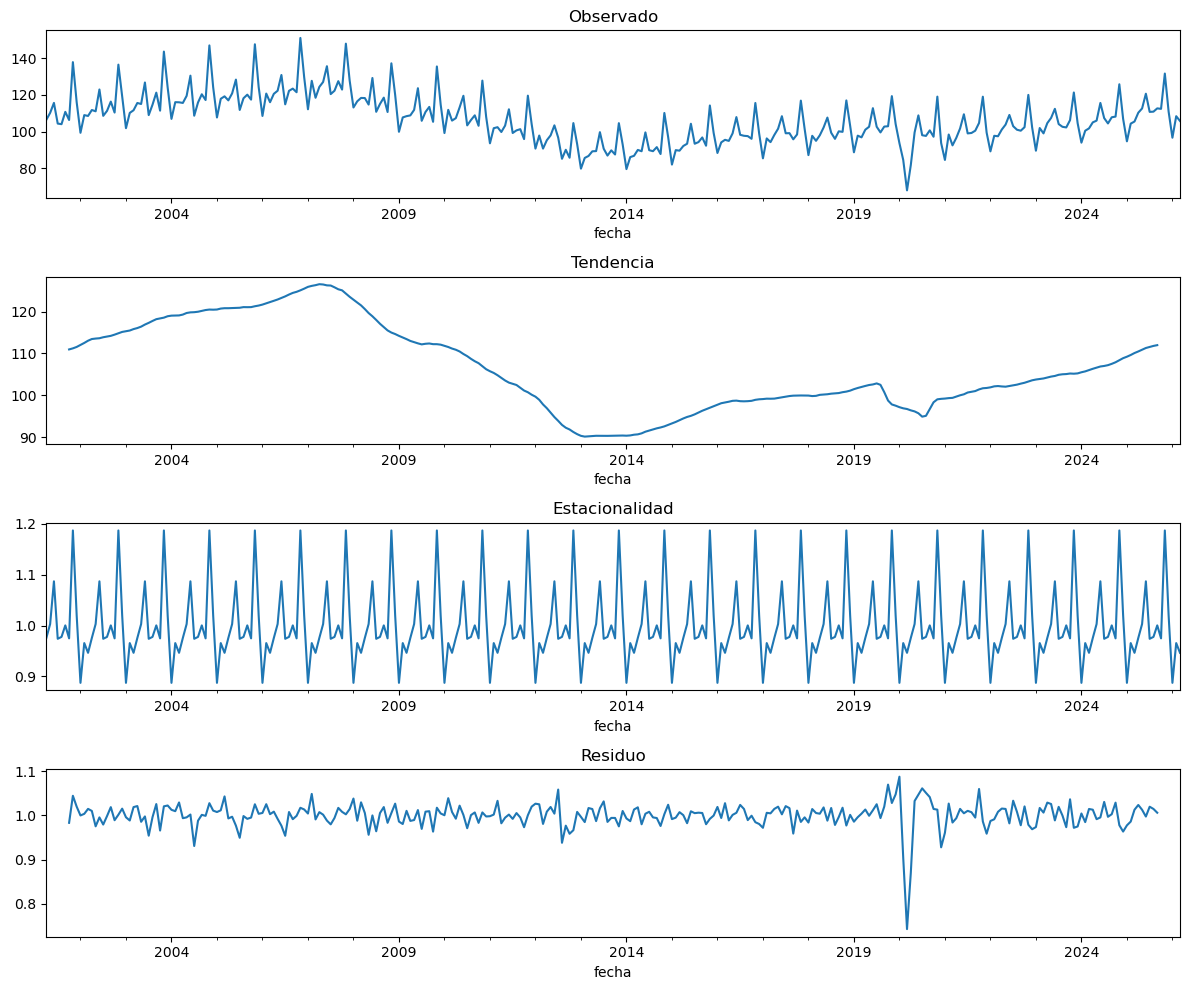

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_indexed = df.set_index('fecha')['valor_icm']

decomposition = seasonal_decompose(df_indexed, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=axes[0], title='Observado')
decomposition.trend.plot(ax=axes[1], title='Tendencia')
decomposition.seasonal.plot(ax=axes[2], title='Estacionalidad')
decomposition.resid.plot(ax=axes[3], title='Residuo')
plt.tight_layout()
plt.savefig('../reports/figures/03_descomposicion_stl.png', dpi=150)
plt.show()

Al realizar la descomposición encontramos lo siguiente:
- Una bajada entre 2008 y 2012 resultado de la crisis financiera del 2008.
- Tendencia al alza desde 2013.
- Ruido aislado sobre caida extema correspondiente con el COVID en 2020.

## Test de estacionariedad

In [10]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(df['valor_icm'].dropna())

print(f'Estadístico ADF: {resultado[0]:.4f}')
print(f'P-value: {resultado[1]:.4f}')
print(f'Valores críticos: {resultado[4]}')

Estadístico ADF: -1.2972
P-value: 0.6304
Valores críticos: {'1%': np.float64(-3.4535050041524245), '5%': np.float64(-2.8717352599720294), '10%': np.float64(-2.5722024776854417)}


Con el test confirmamos la hipotesis nula, la serie no es estacionaria, con p-value de 0.63.

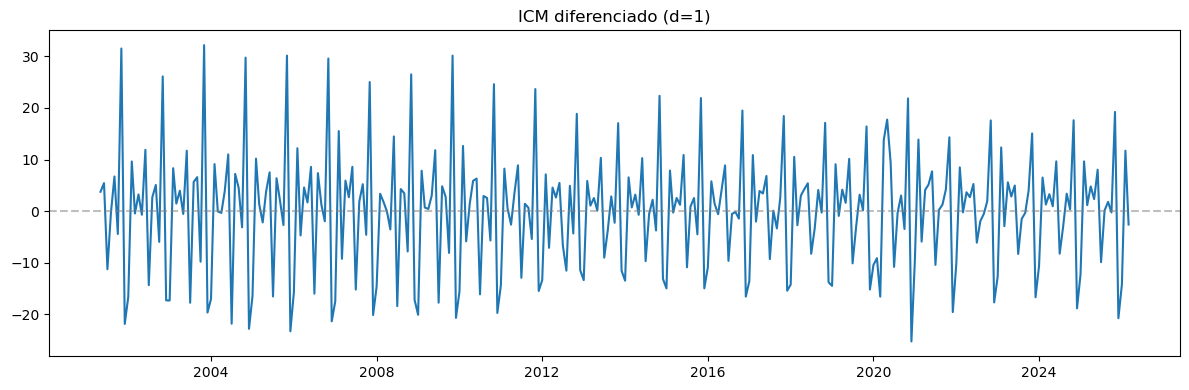

In [13]:
# Se aplica diferenciación para eliminar la tendencia de la serie y tener una serie estacionaria
df['valor_icm_diff'] = df['valor_icm'].diff()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['fecha'], df['valor_icm_diff'])
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('ICM diferenciado (d=1)')
plt.tight_layout()
plt.savefig('../reports/figures/04_serie_diferenciada.png', dpi=150)
plt.show()

In [15]:
# Aplicamos test ADF nuevamente para confirmar la estacionalidad
resultado_diff = adfuller(df['valor_icm_diff'].dropna())

print(f'Estadístico ADF: {resultado_diff[0]:.4f}')
print(f'P-value: {resultado_diff[1]:.4f}')

Estadístico ADF: -4.2687
P-value: 0.0005


- La serie original no es estacionaria (ADF p-value = 0.63) — tiene tendencia.
- Con una diferenciación (d=1) la serie se vuelve estacionaria (p-value < 0.05).
- Implicación para SARIMA: el parámetro d=1.